In [15]:
import hydra
import argparse
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt
import numpy as np
import torch
import logging
import os


In [16]:

#ckpt_dir = "outputs/letters_coupled_exp_bcdf36dc71e6831a478a935d8c7a2b01"
ckpt_dir = "outputs/letters_coupled_exp_12fc678f5d2c72bbd14c7e3c509baba1"

# Resolve and validate checkpoint directory
experiment_dir = os.path.abspath(os.path.expanduser(str(ckpt_dir)))
cfg_path = os.path.join(experiment_dir, 'config.yaml')
ckpt_path = os.path.join(experiment_dir, 'best_model.pt')

# Load trained config and use it as the active config
cfg = OmegaConf.load(cfg_path)
print(cfg)
# Set random seed for reproducibility
if OmegaConf.select(cfg, 'seed') is not None:
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)

dataset = hydra.utils.instantiate(cfg.dataset)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)



{'dataset': {'_target_': 'datasets.letters.Letters', 'data_shape': [2]}, 'encoder': {'_target_': 'encoder.encoders.DistributionEncoderGNN', 'in_dim': '${dataset.data_shape[0]}', 'latent_dim': '${experiment.latent_dim}', 'hidden_dim': '${experiment.hidden_dim}', 'set_size': '${experiment.set_size}', 'layers': 2, 'fc_layers': 2}, 'model': {'_target_': 'layers.MLP', 'in_dims': [2, 16, 16, 16], 'hidden_dim': 64, 'out_dim': 2, 'layers': 4}, 'coupling': {'_target_': 'coupling.ot.OTCollate', 'ot_type': 'sinkhorn', 'ot_params': {'reg': 1.0}}, 'generator': {'_target_': 'generator.energy.EnergyGenerator', 'model': '${model}', 'noise_dim': '${experiment.latent_dim}', 'sigma_min': 1.0, 'm': 8, 'lambda_energy': 1.0}, 'optimizer': {'_target_': 'torch.optim.Adam', '_partial_': True, 'lr': '${experiment.lr}', 'betas': [0.9, 0.999], 'eps': 1e-08, 'weight_decay': 0}, 'scheduler': {'_target_': 'torch.optim.lr_scheduler.ConstantLR', '_partial_': True}, 'training': {'_target_': 'training.Trainer', 'num_epo

!!!!!! 0
!!!!!! 1
!!!!!! 2
!!!!!! 3
!!!!!! 4
!!!!!! 5


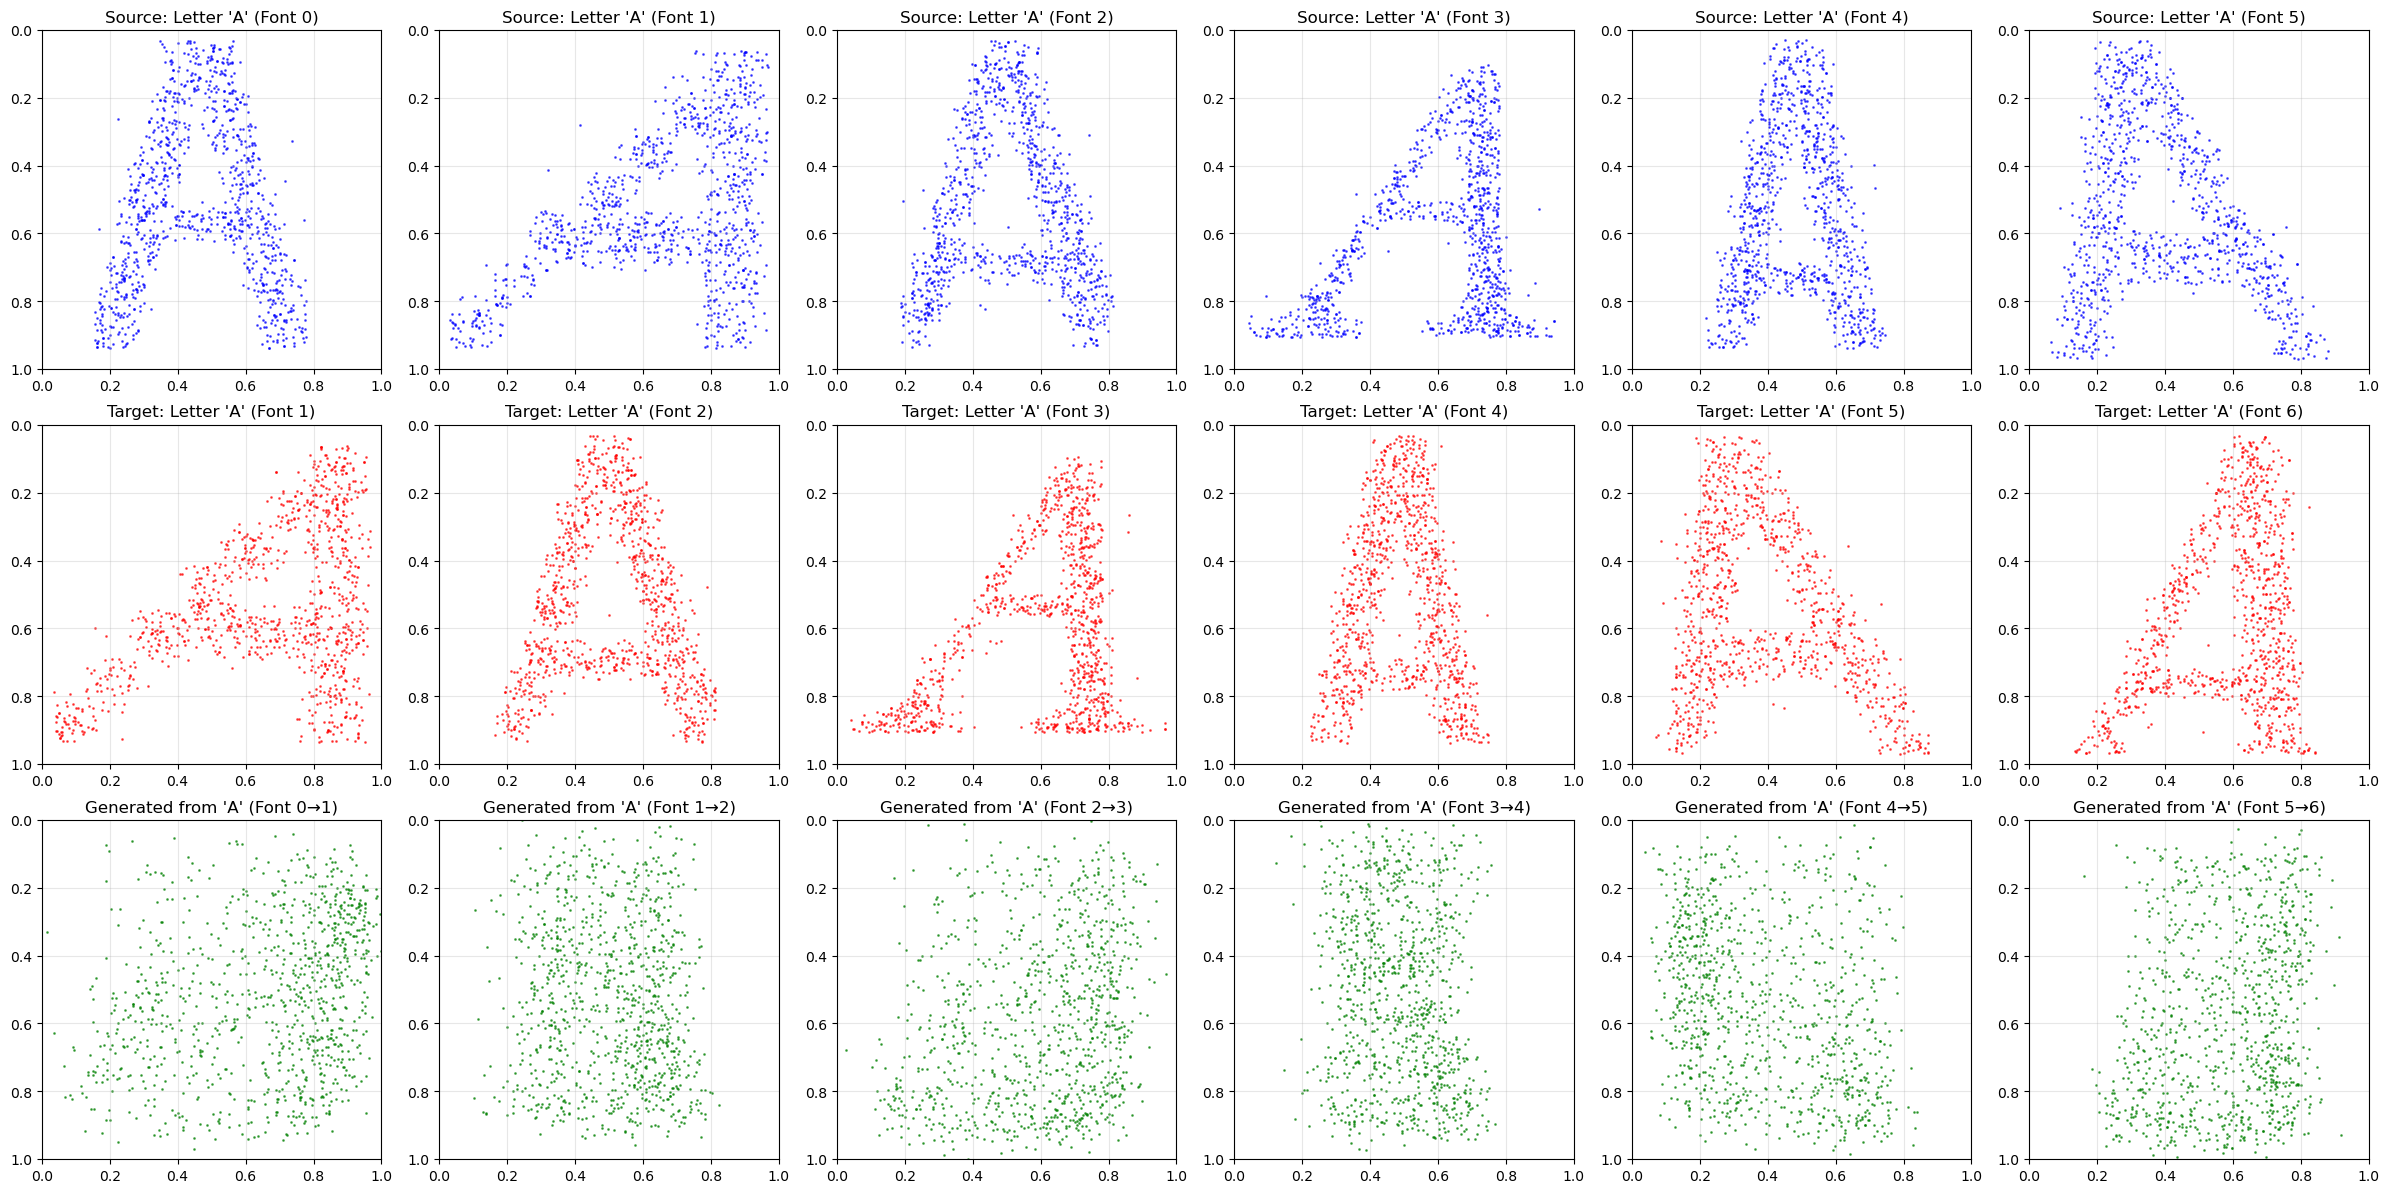

In [18]:
encoder = hydra.utils.instantiate(cfg.encoder).to(device)
generator = hydra.utils.instantiate(cfg.generator).to(device)

checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)

encoder.load_state_dict(checkpoint['encoder_state_dict'])
generator.load_state_dict(checkpoint['generator_state_dict'])
encoder.eval()
generator.eval()


num_examples = min(6, len(dataset))  # Show up to 6 examples

num_rows = 3
fig_height = 12
fig, axes = plt.subplots(num_rows, num_examples, figsize=(4*num_examples, fig_height))
if num_examples == 1:
    axes = axes.reshape(num_rows, 1)


num_sets = 10
for i in range(num_examples):
    print("!!!!!!", i)

    # Determine which letter and fonts we're looking at
    letter = dataset.train_letters[i // (dataset.num_fonts - 1)]
    font = i % (dataset.num_fonts - 1)
    
    # Get dataset item
    source_samples_collection = []
    target_samples_collection = []
    gen_samples_collection = []
    for _ in range(num_sets):
        #print("!!!!!!", i, _)
        item = dataset[i]
        source_samples = item['source_samples']
        target_samples = item['target_samples']
    
        source_samples_collection.append(source_samples)
        target_samples_collection.append(target_samples)
        
        with torch.no_grad():
            # Prepare tensors
            src_tensor = source_samples.to(device)
            tgt_tensor = target_samples.to(device)
            # Encode to latents (batch with single set)
            src_latent = encoder(src_tensor.unsqueeze(0))  # [1, latent_dim]
            #print(cfg.model.get('source_only'))
            if cfg.model.get('source_only', False):
                tgt_latent = None 
            else:
                tgt_latent = encoder(tgt_tensor.unsqueeze(0))  # [1, latent_dim]
            # Generate from source samples conditioned on src/target latents
            gen = generator.sample(src_tensor, src_latent, tgt_latent)  # [1, set_size, 2]
            gen_np = gen.squeeze(0).detach().cpu()
        
        gen_samples_collection.append(gen_np)
    
    source_samples = torch.cat(source_samples_collection, dim=0)
    target_samples = torch.cat(target_samples_collection, dim=0)
    gen_samples = torch.cat(gen_samples_collection, dim=0)

    # Plot source samples
    axes[0, i].scatter(source_samples[:, 0], source_samples[:, 1], 
                    alpha=0.6, s=1, c='blue')
    axes[0, i].set_title(f"Source: Letter '{letter}' (Font {font})")
    axes[0, i].set_xlim(0, 1)
    axes[0, i].set_ylim(0, 1)
    axes[0, i].set_aspect('equal')
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].invert_yaxis()  # Invert y-axis to match image coordinates
    
    # Plot target samples  
    axes[1, i].scatter(target_samples[:, 0], target_samples[:, 1], 
                    alpha=0.6, s=1, c='red')
    axes[1, i].set_title(f"Target: Letter '{letter}' (Font {font+1})")
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_aspect('equal')
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].invert_yaxis()  # Invert y-axis to match image coordinates
    
    axes[2, i].scatter(gen_samples[:, 0], gen_samples[:, 1], alpha=0.6, s=1, c='green')
    axes[2, i].set_title(f"Generated from '{letter}' (Font {font}→{font+1})")
    axes[2, i].set_xlim(0, 1)
    axes[2, i].set_ylim(0, 1)
    axes[2, i].set_aspect('equal')
    axes[2, i].grid(True, alpha=0.3)
    axes[2, i].invert_yaxis()

plt.tight_layout() 

plt.show()




In [ ]:
encoder = hydra.utils.instantiate(trained_cfg.encoder).to(device)
generator = hydra.utils.instantiate(trained_cfg.generator).to(device)

checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)

encoder.load_state_dict(checkpoint['encoder_state_dict'])
generator.load_state_dict(checkpoint['generator_state_dict'])
encoder.eval()
generator.eval()


num_examples = min(6, len(dataset))  # Show up to 6 examples

num_rows = 3
fig_height = 12
fig, axes = plt.subplots(num_rows, num_examples, figsize=(4*num_examples, fig_height))
if num_examples == 1:
    axes = axes.reshape(num_rows, 1)


num_sets = 50
for i in range(num_examples):
    # Get dataset item
    source_samples = []
    target_samples = []
    for _ in range(num_sets):
        item = dataset[i]
        source_samples_set = item['source_samples']
        target_samples_set = item['target_samples']
    
        source_samples.append(source_samples_set)
        target_samples.append(target_samples_set)
        
    source_samples = torch.cat(source_samples, dim=0)
    target_samples = torch.cat(target_samples, dim=0)
    
    # Determine which letter and fonts we're looking at
    letter = dataset.train_letters[i // (dataset.num_fonts - 1)]
    font = i % (dataset.num_fonts - 1)
    
    # Plot source samples
    axes[0, i].scatter(source_samples[:, 0], source_samples[:, 1], 
                    alpha=0.6, s=1, c='blue')
    axes[0, i].set_title(f"Source: Letter '{letter}' (Font {font})")
    axes[0, i].set_xlim(0, 1)
    axes[0, i].set_ylim(0, 1)
    axes[0, i].set_aspect('equal')
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].invert_yaxis()  # Invert y-axis to match image coordinates
    
    # Plot target samples  
    axes[1, i].scatter(target_samples[:, 0], target_samples[:, 1], 
                    alpha=0.6, s=1, c='red')
    axes[1, i].set_title(f"Target: Letter '{letter}' (Font {font+1})")
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_aspect('equal')
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].invert_yaxis()  # Invert y-axis to match image coordinates
    

    with torch.no_grad():
        # Prepare tensors
        src_tensor = source_samples.to(device)
        tgt_tensor = target_samples.to(device)
        # Encode to latents (batch with single set)
        src_latent = encoder(src_tensor.unsqueeze(0))  # [1, latent_dim]
        tgt_latent = None #encoder(tgt_tensor.unsqueeze(0))  # [1, latent_dim]
        # Generate from source samples conditioned on src/target latents
        gen = generator.sample(src_tensor, src_latent, tgt_latent)  # [1, set_size, 2]
        gen_np = gen.squeeze(0).detach().cpu().numpy()
    print("!!!!!!", gen_np.shape)
    axes[2, i].scatter(gen_np[:, 0], gen_np[:, 1], alpha=0.6, s=1, c='green')
    axes[2, i].set_title(f"Generated from '{letter}' (Font {font}→{font+1})")
    axes[2, i].set_xlim(0, 1)
    axes[2, i].set_ylim(0, 1)
    axes[2, i].set_aspect('equal')
    axes[2, i].grid(True, alpha=0.3)
    axes[2, i].invert_yaxis()

plt.tight_layout() 

plt.show()


